# Introdução às Redes Neurais e Deep Learning

## Método dos Gradientes Descendentes 
Referências:

[1] CS168: The Modern Algorithmic Toolbox Lecture #5: Gradient Descent Basics, Tim Roughgarden & Gregory Valiant,April 11, 2016

[2] Ruder, Sebastin, An overview of gradient descent optimization algorithms, arXiv, 2017

[3] Neural Networks for Machine Learning-Lecture 6a Overview of mini-batch gradient descent

[4] Neural Networks for Machine Learning-Lecture 6c The momentum method

[5] Neural Networks for Machine Learning-Lecture 6e rmsprop: Divide the gradient by a running average of its recent magnitude

[6] https://www.geeksforgeeks.org/deep-learning/understanding-gradient-clipping/


O gradiente é um operador diferencial que tem aplicações importantes em física matemática, em métodos núméricos e no caso de interesse aqui, no método dos gradientes descendentes para minimização de funções. As funções que iremos estudar são aquelas que dependem de váriáveis tais como as coordenadas dimensionais de um ponto, ou no caso específico de redes neurais, uma função de erro tal como o erro médio quadrático $L=\sum_{i=1}^N (\hat{y}_i-y_i)^2$, onde $\hat{y}_i=\sum W_iX_i$, $W_i$ são os pesos ou parâmetros como os que vimos no caso do perceptron e $X_i$ são os dados ou caracteríticas de entrada. Neste caso podemos definir a função erro $L$ como uma função de várias váriáveis $L(W,Y,X)$. 

Seja uma função $f(x,y)$ definida em função das variáveis $x$ e $y$. Uma mudança do ponto $(x,y)$ levará à uma consequente alteração no valor de $f$. Considere agora um deslocamento diferencial $d\textbf{l}$, expresso como um vetor porque a sua direção e sentido serão importantes nos argumentos que seguem:

$$d\textbf{l}=dx\,\textbf{e}_1 +dy\,\textbf{e}_2$$
onde $\textbf{e}_i$ são os vetores base unítários do espaço considerado. A variação resultante em $f$ é expressa pela sua diferencial total, ou seja
$$df=\frac{\partial f}{\partial x}dx+\frac{\partial f}{\partial y}dy$$
que por sua vez pode ser reescrita como 
$$df=\left(\frac{\partial f}{\partial x}\textbf{e}_1+\frac{\partial f}{\partial y}\textbf{e}_2\right)\cdot\left(dx\,\textbf{e}_1 +dy \,\textbf{e}_2\right)$$
Na expressão acima foi utilizado o fato que embora o primeiro termo do lado direito não seja um vetor, mas um operador vetorial de derivadas parciais, sua combinação com o segundo termo (deslocamento diferencial $d\textbf{l}$)  se dá sob as regras do produto escalar, representado por $\cdot$ na equação. O  operador diferencial é o **gradiente** da função $f$, e é denotado ${\bf{\nabla}}f$. Assim $df={\bf{\nabla}}f\cdot d{\bf{l}}$, e a variação diferencial em $f$ depende sobretudo da direção do gradiente relativa aquela do deslocamento. Temos portanto que 
$$df=\left|\mathbf{\nabla}f\right|\left|d\mathbf{l}\right|\cos\theta$$
e $\theta$ é o ângulo entre $\mathbf{\nabla}f$ e $\mathbf{d}l$. Se $d\mathbf{l}$ e $\mathbf{\nabla}f$ são colineares, $df=\left|d\mathbf{l}\right|\left|\mathbf{\nabla}f\right|$, a máxima variação possível. Se ambos são perpendiculares entre si então $df=0$, e finalmente se ambos são contrariamente orientados teremos $df=-\left|d\mathbf{l}\right|\left|\mathbf{\nabla}f\right|$, máxima redução no valor de $f$. Este último resultado nos leva ao método do gradiente descendente. Suponha que temos uma função avaliada em um dado ponto $f(x^*,y^*)$ , e desejo encontrar o ponto $(x_0,y_0)$ no qual esta função tenha seu mínimo valor. Podemos encontrar um caminho de $(x^*,y^*)$ até $(x_0,y_0)$ atávés da seguinte regra de atualização:
$$ \mathbf{x}_{\text{novo}}=\mathbf{x}_{\text{atual}}-\eta \mathbf{\nabla}f$$
Onde $\mathbf{x}$ é o vetor de coordenadas e $\eta$ é a taxa de aprendizado (*learning rate*), um **hyperparâmetro** importante que controla quão rapidamente o modelo aprende através do comprimento do passo usado na atualização de $\mathbf{x}$.

De volta à aplicação em redes neurais, considere que a função em questão seja uma função de erro, função custo,ou  *Loss function L*  , como o erro médio quadrático. Suponha que *L* seja algo como $L=W_1^2+W_2^2$. Então podemos atualizar o vetor de pesos ou parâmetros $\mathbf{W}$ como anteriormente, ou seja  
$$ \mathbf{W}_{\text{novo}}=\mathbf{W}_{\text{atual}}-\eta \mathbf{\nabla}L.$$
Essas ideias estão ilustradas na figura abaixo:

<div>
<img src="Files\ChatGPT QuadFun.png" width="500" height="800">   
</div>
Fonte: Imagem gerada com o auxílio de IA-ChatGPT.

Vamos agora estudar um exemplo do que foi discutido até agora, aplicando o método dos gradientes descendentes para encontrar o mínimo de uma função $f(x)$ quadrática, e observar o comportamento do método para diferentes valores da taxa de eprendizado. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Função custo e gradiente da função custo:

In [2]:
def cost_func(x):
    return x**2 - 4 * x + 1
    
def gradient(x):
    return 2*x - 4
    

Método dos gradientes descendentes e visualização das atualizações:

In [3]:
def gradient_descent_curve(ax, learning_rate):
    final_x, history = gradient_descent(gradient, initial_x, learning_rate, iterations, tolerance)

    ax.plot(x_values, y_values, label=f'Cost function: $J(x) = x^2 - 4x + 1$', lw=3, color='blue')

    ax.scatter(history, [cost_func(x) for x in history], s=100,color='green', zorder=5, label='Steps')
    ax.plot(history, [cost_func(x) for x in history], 'g--', lw=2, zorder=5)

    ax.annotate('Start', xy=(history[0], cost_func(history[0])), xytext=(history[0], cost_func(history[0]) + 15),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    ax.annotate('End', xy=(final_x, cost_func(final_x)), xytext=(final_x, cost_func(final_x) + 10),
                arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
    
    ax.set_title(f'Learning Rate: {learning_rate}')
    ax.set_xlabel('Input feature: x')
    ax.set_ylabel('Cost: J')
    ax.grid(True, alpha=0.5, ls='--', color='grey')
    ax.legend()

def gradient_descent(gradient, start, learn_rate, max_iter, tol):
    x = start
    steps = [start] 

    for _ in range(max_iter):
        diff = learn_rate * gradient(x)
        if np.abs(diff) < tol:
            break
        x = x - diff
        steps.append(x)

    return x, steps
    


Definição dos parâmetros iniciais e resultados

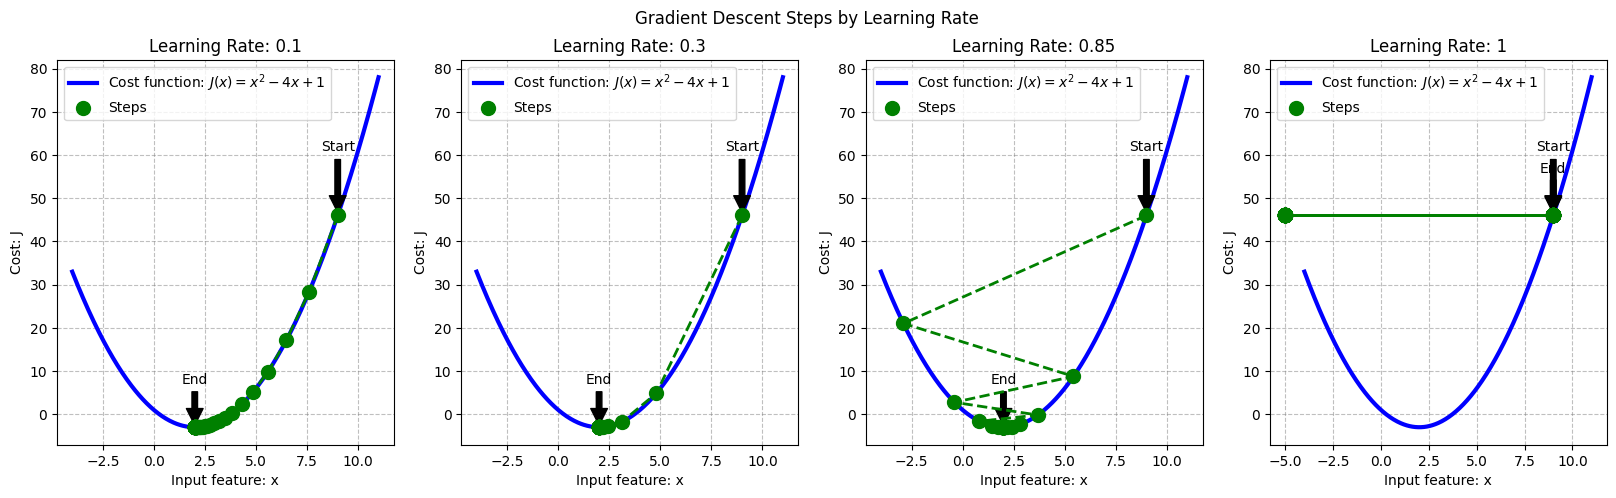

In [4]:
x_values = np.linspace(-4, 11, 400)
y_values = cost_func(x_values)
initial_x = 9
iterations = 100
tolerance = 1e-15
learning_rates = [0.1, 0.3, 0.85, 1]


fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Gradient Descent Steps by Learning Rate')
for ax, lr in zip(axs, learning_rates):
    gradient_descent_curve(ax=ax, learning_rate=lr)

## Método dos Gradientes Descendentes Estocástico (SGD)

Considere o problema de minimização da função de perda/custo *MSE* abaixo:

$$ \mathbf{W}=\mathbf{W}-\eta\mathbf{\nabla}L$$
onde, para um problema de regressão linear,
$$\hat{y}(\mathbf{W})=b_0+\mathbf{W}.\mathbf{x}.$$

Então, 

$$L=\frac{1}{M}\sum_i^M(\hat{y}_i-{y}_i)^2\rightarrow \frac{\partial L}{\partial \mathbf{W}}=\frac{2}{m}\sum_i(\hat{y}_i-y_i).\frac{\partial \hat{y}_i}{\partial \mathbf{W}}=\frac{2}{m}\sum_i(\hat{y}_i-y_i).\mathbf{x}$$
e
$$ \frac{\partial L}{\partial b_0}=\frac{2}{m}\sum_i(\hat{y}_i-y_i).\frac{\partial \hat{y}_i}{\partial b_0}=\frac{2}{m}\sum_i(\hat{y}_i-y_i).$$
### Método do Gradiente Descendente Estocástico

No método do gradiente descendente estocástico (*Stochastic Gradient Descent — SGD*), o gradiente é calculado utilizando **uma amostra de treinamento ou um pequeno subconjunto de amostras**, em vez de utilizar todo o conjunto de treinamento a cada atualização dos pesos.

Além da taxa de aprendizado (*learning rate*), utilizamos o tamanho do lote (*batch size*), que corresponde ao **número de amostras de treinamento utilizadas para calcular o gradiente em cada passo de atualização**.

No método do gradiente descendente tradicional, também chamado de **Batch Gradient Descent**, o *batch size* é igual ao número total de amostras do conjunto de treinamento. Assim, todos os dados são utilizados para calcular o gradiente antes de cada atualização dos pesos.

No SGD básico, o *batch size* é igual a 1. Nesse caso, os pesos são atualizados após o cálculo do gradiente de cada amostra individual.

Quando utilizamos um *batch size* maior que 1, mas menor que o número total de amostras, temos o chamado **Mini-Batch Gradient Descent**.

Portanto:

* **Batch Gradient Descent:** utiliza todas as amostras em cada atualização;
* **Mini-Batch Gradient Descent:** utiliza um subconjunto das amostras;
* **Stochastic Gradient Descent (SGD):** utiliza uma amostra por vez.

O *learning rate* e o *batch size* são **hiperparâmetros** do processo de treinamento. Eles são definidos externamente ao processo de aprendizagem dos pesos e influenciam a velocidade, a estabilidade e o comportamento do treinamento.
  


### Implementação didática do SGD em Python, com 4 otimizadores:

In [5]:
import numpy as np

In [6]:
def sgd(X, y, learning_rate=0.1, epochs=1000, batch_size=1,clip=True,optimizer='sgd', momentum=0.9, beta=0.9, 
        beta1=0.9,beta2=0.999,epsilon=1e-8,verbose=True ):
    m = len(X)
    
    # Adiciona as bias em X (X_0 = 1)
    X_bias = np.c_[np.ones((m, 1)), X]
    # converte y em um array (m,1)
    y = y.reshape(-1, 1)
    
    # Parâmetros iniciais:
    # w[0] = bias
    # w[1] = peso associado a X 
    w = np.zeros((2, 1))
    w=np.array([[7.9],[-4.9]])

    # Variáveis auxiliares dos otimizadores
    m_w=np.array([[0],[0]])
    v_w=np.array([[0],[0]])
    s_w=np.array([[0],[0]])
    
    t=0

    # Guarda o caminho percorrido pelos parâmetros
    loss_history = [] 
    w_history = np.zeros((epochs + 1, 2))
    w_history[0] = w.ravel()
    
    for epoch in range(epochs):
    
        w_history[epoch + 1, :] = w.ravel()
        
        # embaralha os dados 
        indices = np.random.permutation(m)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            # Seleciona um lote (bath) dos dados
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # calcula o gradiente
            current_batch_size = len(X_batch)
            gradients = (2 / current_batch_size* X_batch.T.dot(X_batch.dot(w) - y_batch))

            # Gradient clipping
            if clip:
                clip_value = 1.0
                gradients = np.clip(gradients,-clip_value,clip_value)
                
            # SGD
            if optimizer == 'sgd':

                w -= learning_rate * gradients
                
            # Momentum
            elif optimizer == 'momentum':

                m_w = momentum * m_w + learning_rate * gradients
                w -= m_w

            # RMSprop
            elif optimizer == 'rmsprop':

                v_w = beta * v_w + (1 - beta) * gradients**2
                w -= (learning_rate * gradients / (np.sqrt(v_w) + epsilon))

            # Adam
            elif optimizer == 'adam':

                t += 1
                # Primeiro momento
                m_w = (beta1 * m_w + (1 - beta1) * gradients)

                # Segundo momento
                v_w = (beta2 * v_w+ (1 - beta2) * gradients**2)

                # Correção do viés
                m_hat = m_w / (1 - beta1**t)
                v_hat = v_w / (1 - beta2**t)

                w -= (learning_rate * m_hat / (np.sqrt(v_hat) + epsilon))

            else:
                raise ValueError("optimizer deve ser: " "'sgd', 'momentum', 'rmsprop' ou 'adam'" )

        # Custo (Mean Squared Error)
        predictions = X_bias.dot(w)
        loss = np.mean((predictions - y) ** 2)

        # loss a cada  10 epochs
        if epoch % 5 == 0:
            if verbose:
                print(f"Epoch {epoch}, Loss: {loss}")
            loss_history.append(loss)
    
    return w_history, loss_history

#### Rotinas `trace()`para traçado da reta calculada para aproximação linear no problema de regressão e `isolinhas()`para desenho das curvas de nível da função custo com o trajeto dos pesos em direção ao mínimo.

In [7]:
import matplotlib.pyplot as plt

# Gráfico de curvas de nível com convergência dos pesos e bias via SGD
def isolinhas(x,y):
    losses,w,b=get_loss(x,y)
    levels=np.sort(np.array(loss_history))
    
    plt.figure()
    title='Convergência do Método dos Gradientes Descendentes'
    cp=plt.contour(w,b, losses,levels,colors='black', linestyles='dashed', linewidths=1)
    plt.clabel(cp, inline=1, fontsize=10)
    plt.contourf(w, b, losses,levels,alpha=0.5)
    plt.scatter(w_model[:,0],w_model[:,1],c='r',marker='+')
    plt.plot(w_model[:,0],w_model[:,1],c='r')
    plt.xlabel('b')
    plt.ylabel('W')
    plt.title(title)
    plt.show()
    
# Cáculo das perdas (loss)
def mse_loss(y_true, y_pred):
  return ((y_true - y_pred) ** 2).mean()

# retorna o mapa de perdas
def get_loss(x,y):
    w=np.zeros(101)
    b=np.zeros(101)
    
#   mapa das perdas em um gráfico bidimensional de pesos e bias na faixa (-5,8)
    losses = [[0.0] * 101 for _ in range(101)]
    for iw in range(101):
      for ib in range(101):
        w[iw] = -5.0 + 13.0 * iw / 100.0
        b[ib] = -5.0 + 13.0 * ib / 100.0
    
        ywb = x * w[iw] + b[ib]
        losses[iw][ib] = mse_loss(y,ywb)
    return losses,w,b


def trace():
# traçado da reta de ajuste dos dados do problema
#===
    plt.figure()
    title='aproximação Linear dos pontos do problema'
    plt.scatter(X, y, facecolors='b', edgecolors='b')
    plt.plot(
      [X.min(), X.max()],
      [w_final[1] * X.min() + w_final[0], w_final[1] * X.max() + w_final[0]],
      c='r')
    plt.title(title)

In [8]:
# geração de dados (pontos randômicos)
X = 2 * np.random.rand(500)  
y = 4 + 3 * X + np.random.randn(X.shape[0]) 

In [9]:
# SGD
w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=150, batch_size=1,optimizer='sgd', verbose=False)
w_final=w_model[-1]

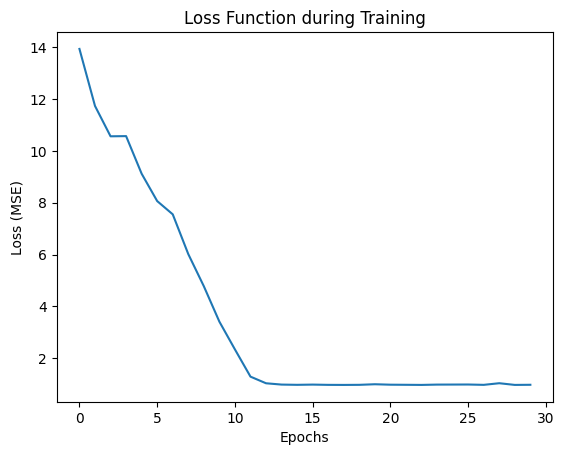

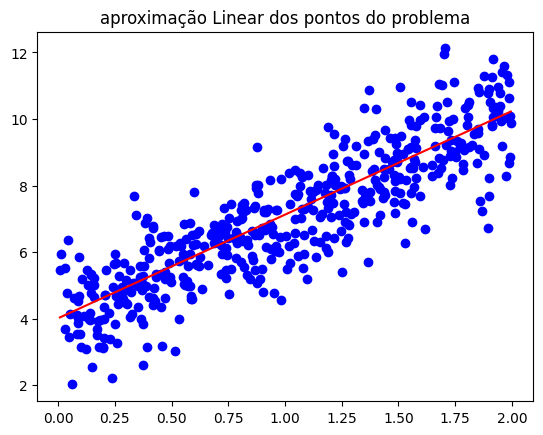

In [10]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

trace()

 #### *Gradient Clipping*  
É o processo que ajuda a manter a estabilidade numérica, impedindo que os gradientes cresçam demais. Ao treinar uma rede neural, os gradientes da função de perda são calculados por meio de retropropagação. No entanto, se esses gradientes se tornarem muito grandes, as atualizações dos pesos do modelo também podem se tornar excessivamente grandes, levando à instabilidade numérica. Isso pode resultar na produção de valores NaN (Not a Number - Não é um Número) ou erros de *overflow* o que pode ser problemático. Esse problema é frequentemente chamado de "explosão de gradiente" e pode ser resolvido truncando o gradiente em um valor desejado. Neste exemplo utilizamos clipping por valor, limitando individualmente cada componente do gradiente.

In [11]:
import numpy as np

# dados do problema
# ===
np.random.seed(20240215)
n = 50
X = np.array(np.random.randn(n))
y = np.array(0.775 * X**2 + 1.0 * X +0.5+ 0.3 * np.random.randn(n))

Neste exemplo, os dados são gerados por uma relação quadrática, enquanto o modelo utilizado continua sendo linear. Portanto, o treinamento procura os valores de $w$ e $b$ que produzem a melhor aproximação linear dos dados segundo o MSE.

##### Optimização dos pesos e bias - sgd sem *gradient clipping*

In [12]:
w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=30, batch_size=1,clip=False,optimizer='sgd',verbose=False)
w_final=w_model[-1]

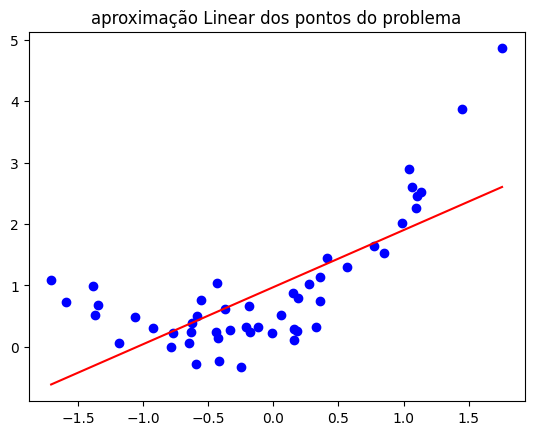

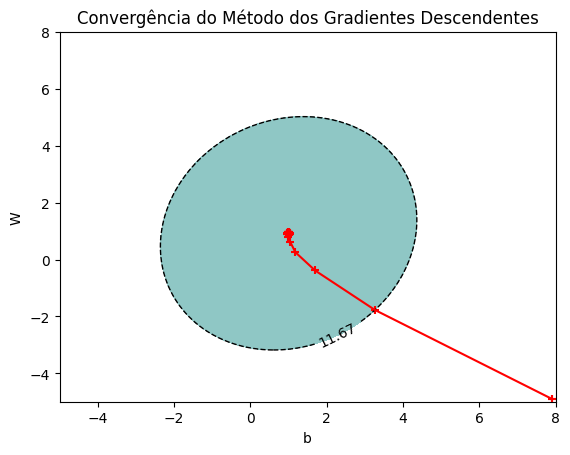

In [13]:
trace()
isolinhas(X,y)

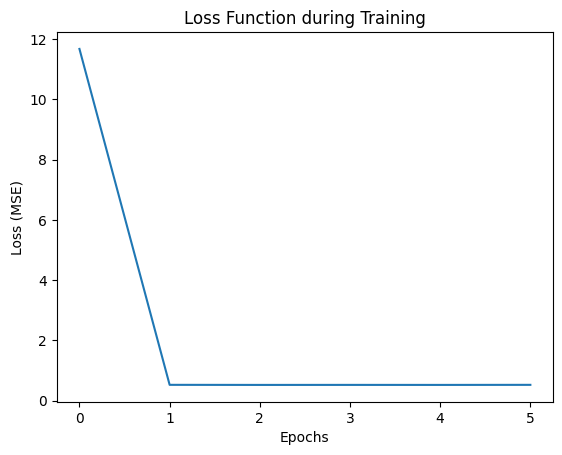

In [14]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

##### Optimização dos pesos e bias - sgd com *gradient clipping*

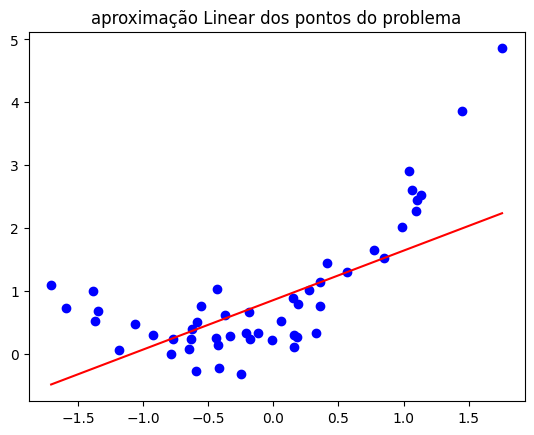

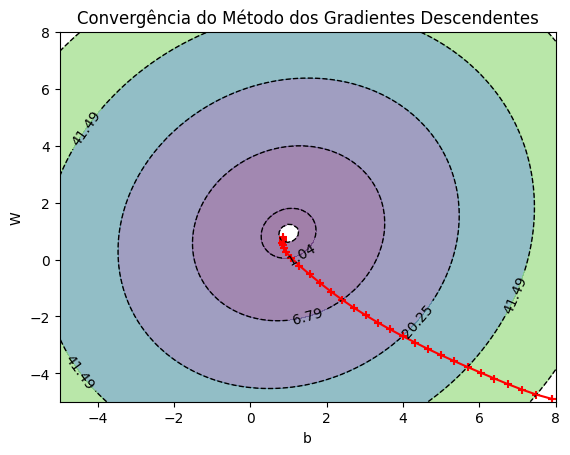

In [15]:
w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=30, batch_size=1,optimizer='sgd',verbose=False)
w_final=w_model[-1]

trace()
isolinhas(X,y)

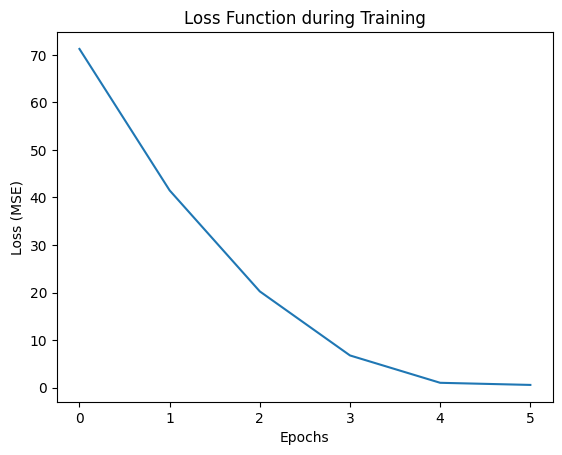

In [16]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

#### SGD com *momentum*

$$ m_t =momentum *m_t+\eta \frac{\partial L}{\partial W}$$
$$ W=W-m_t$$

Características do SGD com momentum:

    Acumula a média móvel dos gradientes anteriores
    Auxilia a atravessar por pequenas variações locais
    Pode acelerar a convergência
    Favorece as dimensões onde o gradiente aponta na mesma direção e reduz a atualização nas dimensões onde os gradientes mudam de direção, levando a menor oscilação.

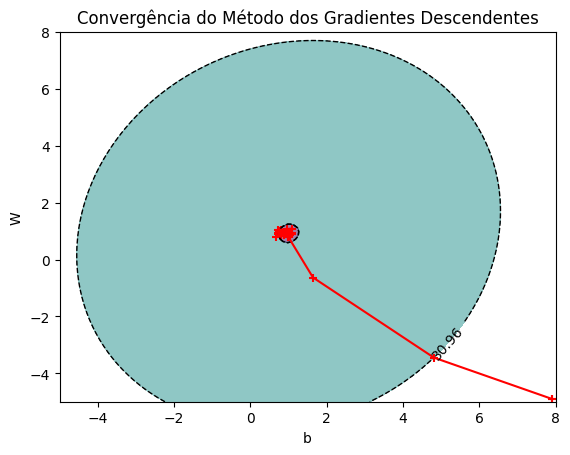

In [17]:
# Optimização dos pesos e bias - sgd com momentum
# ===

w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=30, batch_size=1,optimizer='momentum', verbose=False)
w_final=w_model[-1]

isolinhas(X,y)

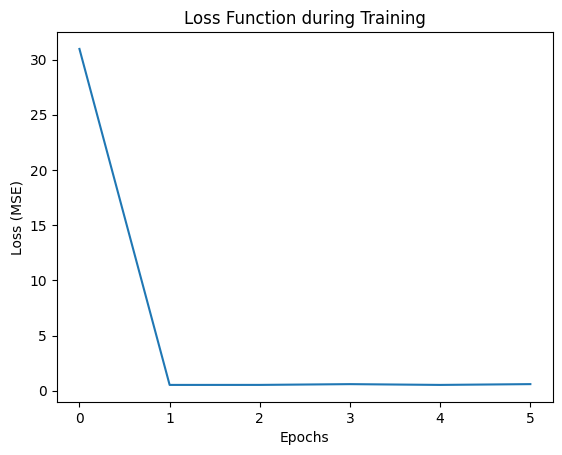

In [18]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

#### SGD com RMSprop (RMS propagation)

$$v_t=\beta v_t+(1-\beta)(\frac{\partial L}{\partial w})^2$$

$$W(t+1)=w(t)-\eta\frac{1}{\sqrt{v_t}+\epsilon}\frac{\partial L}{\partial w}$$

onde $v_t=E(grad^2)$ é uma média móvel exponencial dos gradientes ao quadrado. A raiz quadrada de $E(grad^2)$ fornece uma medida da magnitude recente dos gradientes e é utilizada para adaptar o tamanho do passo de cada parâmetro.

Essencialmente, o que as equações acima fazem é:

* Adaptar a taxa de aprendizado para cada parâmetro, o que é crucial, pois parâmetros diferentes podem exigir taxas de aprendizado diferentes.
* Lidar com o problema do "gradiente evanescente", comum em redes neurais, onde os gradientes se tornam muito pequenos devido à retropropagação. Esse efeito é mitigado pela normalização dos gradientes.
* Balancear o tamanho do passo:

Para parâmetros com gradientes grandes (atualizados com frequência), a soma dos gradientes ao quadrado no denominador será grande, reduzindo a taxa de aprendizado efetiva.
Para parâmetros com gradientes pequenos (atualizados com pouca frequência), o denominador será menor, aumentando a taxa de aprendizado efetiva.

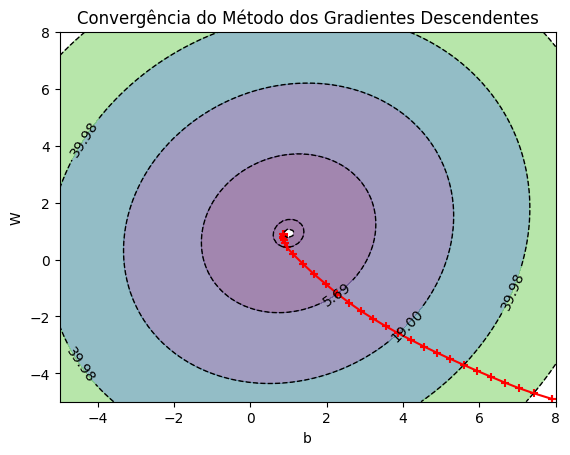

In [19]:
# Optimização dos pesos e bias - MSEprop
# ===

w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=30, batch_size=1,optimizer='rmsprop', verbose=False)
w_final=w_model[-1]

isolinhas(X,y)

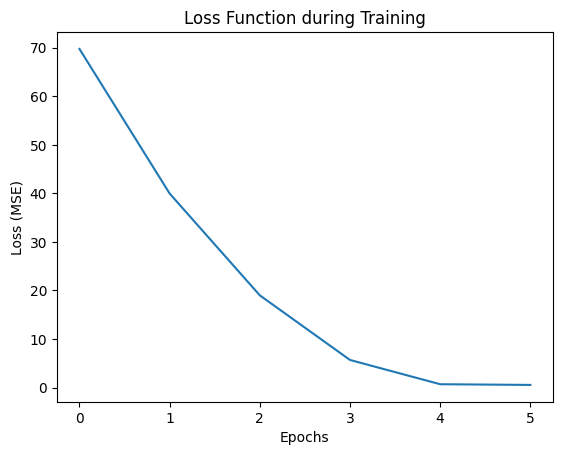

In [20]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

#### SGD com Adam(adaptive Moment Estimation)

$$m_t=\beta_1 m_{t-1}+(1-\beta_1)\frac{\partial L}{\partial w}$$
$$v_t=\beta_2 v_{t-1}+(1-\beta_2)(\frac{\partial L}{\partial w})^2$$

$m_t$ e $v_t$ são os valores médios (estimativa) do primeiro e segundo momento dos gradientes, ou ainda, dos gradientes e seus quadrados. Considere o primeiro momento $m_t$: substituindo $m_{t-1}$, temos

$$m_t=\beta_1[\beta_1m_{t-2}+(1-\beta_1)\frac{\partial L}{\partial w}|_{t-1}]+(1-\beta_1)\frac{\partial L}{\partial w}|_t= (1-\beta_1)\frac{\partial L}{\partial w}|_t+ (1-\beta_1)\beta_1\frac{\partial L}{\partial w}|_{t-1}+\beta_1^2m_{t-2}.$$
de forma que, continuando a expansão, teremos:

$$m_t= (1-\beta_1)\frac{\partial L}{\partial w}|_t+ (1-\beta_1)\beta_1\frac{\partial L}{\partial w}|_{t-1}+(1-\beta_1)\beta_1^2\frac{\partial L}{\partial w}|_{t-2}+\textellipsis$$

os pesos $\beta_i$ serão $1-\beta_1,\; (1-\beta_1)\beta_1, (1-\beta_1)\beta_1^2,\; (1-\beta_1)\beta_1^3,\;\textellipsis$. Como $0<\beta_1<1$, os pesos diminuem exponencialmente. Se $\beta_1=0.9$, tem-se que

gradiente atual       → peso 0,100

gradiente anterior    → peso 0,090

2 passos atrás        → peso 0,081

3 passos atrás        → peso 0,073

4 passos atrás        → peso 0,066

...

Portanto, gradientes recentes têm maior influência e gradientes antigos têm influência progressivamente menor. É daí que vem o nome média móvel exponencialmente decrescente (exponentially decaying moving average).

Como esses vetores são inicializados com valores nulos, eles apresentam um viés em direção à zero, principalmente nos passos iniciais, e portanto uma correção é realizada nas estimativas:
$$\hat{m_t}=\frac{m_t}{1-\beta_1^t}$$
$$\hat{v_t}=\frac{v_t}{1-\beta_2^t}$$

e daí

$$w(t+1)=w(t)-\eta \frac{1}{\sqrt{\hat{v_t}}+\epsilon}\hat{m_t}$$

O primeiro momento atua como momentum, acumulando gradientes passados ​​para dar à otimização um senso de direção e velocidade. Isso ajuda o Adam a se mover mais rápido em direções consistentes e amortece oscilações em cenários de gradientes com ruído.

O segundo momento, como no RMSprop, adapta a taxa de aprendizado para cada parâmetro. Ele normaliza efetivamente as atualizações dos parâmetros, desacelerando o aprendizado para parâmetros com gradientes grandes e acelerando-o para aqueles com gradientes pequenos. Isso permite que o Adam manipule parâmetros em diferentes escalas de forma eficaz.

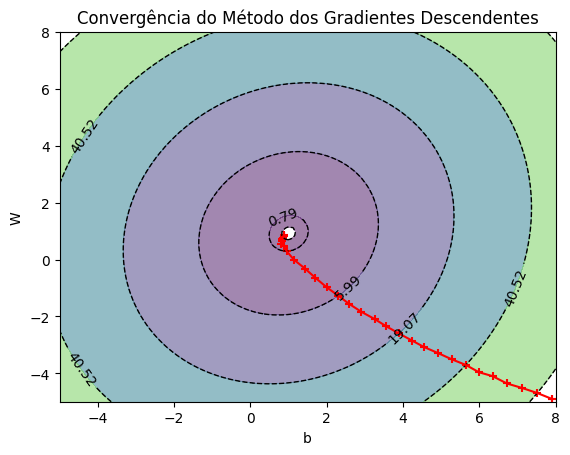

In [21]:
# Optimização dos pesos e bias - sgd - adam
# ===

w_model, loss_history = sgd(X, y, learning_rate=0.01, epochs=30, batch_size=1,optimizer='adam', verbose=False)
w_final=w_model[-1]

isolinhas(X,y)

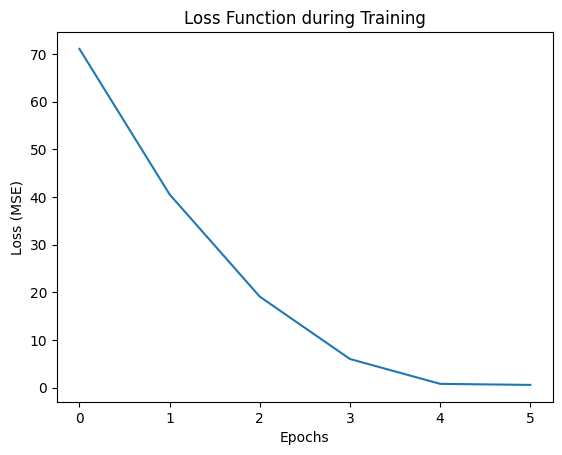

In [22]:
# Plot the cost history
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Loss Function during Training')
plt.show()

Neste exemplo simples, RMSprop e Adam apresentam trajetórias muito semelhantes. Isso ocorre porque os gradientes variam suavemente e a função de custo é aproximadamente quadrática. Nessas condições, a média móvel dos gradientes utilizada pelo Adam permanece próxima do gradiente atual, fazendo com que seu comportamento se aproxime do RMSprop. A diferença entre os métodos torna-se mais evidente em problemas nos quais os gradientes variam mais rapidamente, apresentam diferentes escalas entre os parâmetros ou possuem maior ruído. 

Em um novo exemplo, usaremos uma versão da nossa rotina `sgd`com uma função alongada e acrescentaremos uma perturbação ao gradiente para salientar as diferenças entre o RMSprop e Adam. O objetivo é observar como os diferentes otimizadores respondem quando a direção do gradiente não é perfeitamente estável.

In [23]:
# Função de custo e gradiente:
import numpy as np
import matplotlib.pyplot as plt

# Função de custo
def cost_func(w):
    w1, w2 = w
    return w1**2 + 20*w2**2

# Gradiente
def gradient(w):
    w1, w2 = w

    return np.array([
        2*w1,
        40*w2
    ])

##### `sgd_pert`: nesta versão são usadas as definições da função e seu gradiente acima, assim como uma perturbação é adicionada ao gradiente. 

In [24]:
def sgd_pert(w_initial,learning_rate=0.01,iterations=100,optimizer='sgd',momentum=0.9,beta=0.9,beta1=0.9,
             beta2=0.999,epsilon=1e-8,noise=False):

    w = w_initial.copy()
    
    # Variáveis utilizadas pelos diferentes métodos
    velocity = np.zeros_like(w)
    s = np.zeros_like(w)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    
    # Histórico dos parâmetros
    w_history = np.zeros((iterations + 1, 2))
    w_history[0] = w
    
    for t in range(1, iterations + 1):

        # Gradiente da função
        g = gradient(w)

        # Pequena perturbação determinística
        if noise:
            perturbation = np.array([
                3.0 * np.sin(0.5 * t),
                3.0 * np.cos(0.5 * t)
            ])
            g = g + perturbation

        # SGD
        if optimizer == 'sgd':

            w -= learning_rate * g

        # Momentum
        elif optimizer == 'momentum':
            velocity = momentum * velocity+ learning_rate * g

            w -= velocity

        # RMSprop
        elif optimizer == 'rmsprop':
            s = beta * s+ (1 - beta) * g**2
            
            w -= learning_rate* g / (np.sqrt(s) + epsilon)

        # Adam
        elif optimizer == 'adam':
            m = beta1 * m+ (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g**2
            
            # Correção do viés
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)

            w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        else:
            raise ValueError("optimizer deve ser: ""'sgd', 'momentum', 'rmsprop' ou 'adam'")

        # Guarda posição atual
        w_history[t] = w

    return w_history

##### `plot_results`: nesta rotina são mostradas as curvas de nível da função junto com as trajetórias de cada otimizador.

In [25]:
def plot_results(optimizers,results):
    w1 = np.linspace(-5, 5, 400)
    w2 = np.linspace(-5, 5, 400)
    W1, W2 = np.meshgrid(w1, w2)
    Z = W1**2 + 20*W2**2
    
    plt.figure(figsize=(10, 8))

    levels = np.logspace(-2, 3, 20)
    plt.contour(W1,W2,Z,levels=levels)
    
    for optimizer in optimizers:
    
        history = results[optimizer]
    
        plt.plot(history[:, 0],history[:, 1],label=optimizer)
    
    plt.scatter(w_initial[0],w_initial[1],marker='o',s=80)
    
    plt.xlabel(r'$w_1$')
    plt.ylabel(r'$w_2$')
    plt.title('Trajetórias dos métodos de otimização')
    plt.legend()
    plt.grid(True)
    
    plt.show()
    
    

##### Teste inicial sem perturbação:

In [26]:
w_initial = np.array([4.0, 4.0])
optimizers = ['sgd','momentum','rmsprop','adam']
results = {}
for optimizer in optimizers:
    results[optimizer] = sgd_pert(w_initial=w_initial,learning_rate=0.02,iterations=400,optimizer=optimizer,
                                  noise=False)

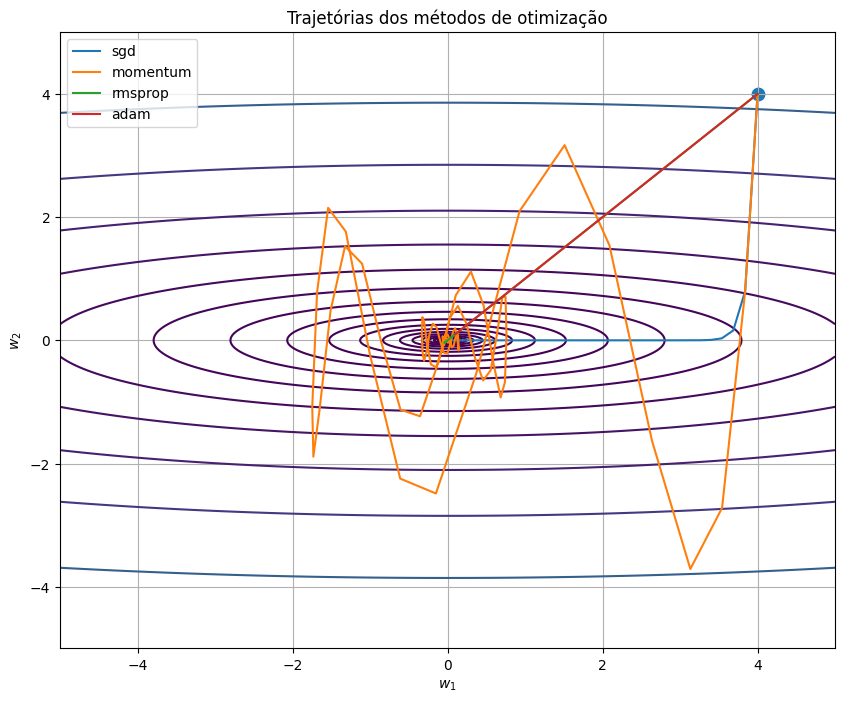

In [27]:
plot_results(optimizers,results)

##### Teste **com** perturbação:

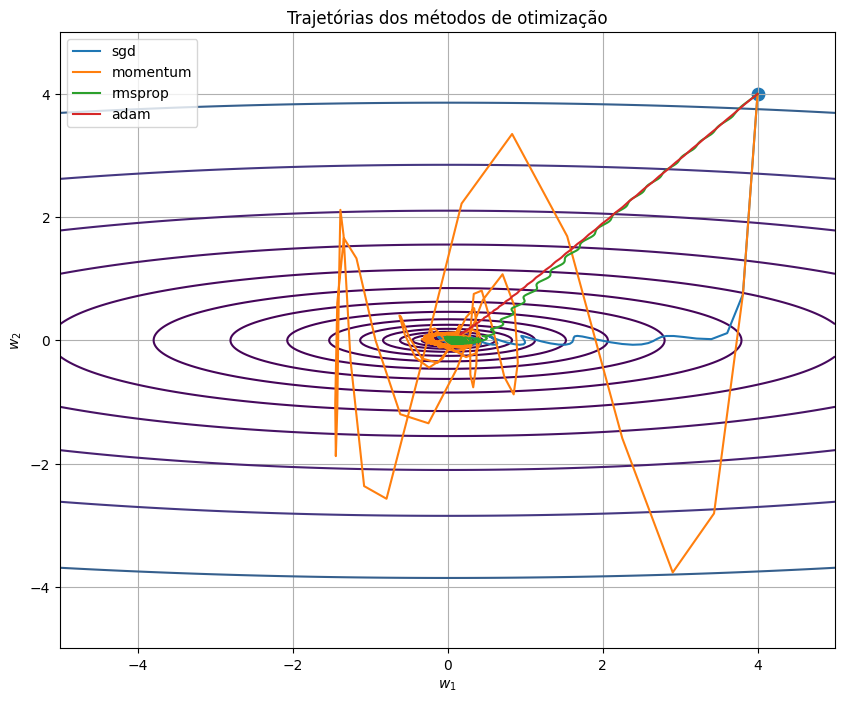

In [28]:
results = {}
for optimizer in optimizers:
    results[optimizer] = sgd_pert(w_initial=w_initial,learning_rate=0.02,iterations=400,optimizer=optimizer,
                                  noise=True)
plot_results(optimizers,results)

##### **Conclusão**

Os experimentos mostram que o comportamento dos diferentes métodos de otimização depende das características da função de custo e dos gradientes.

No primeiro exemplo, em que a função de custo é simples e os gradientes variam de maneira suave, RMSprop e Adam apresentam trajetórias muito semelhantes. Isso ocorre porque, nessas condições, a média móvel dos gradientes utilizada pelo Adam permanece próxima do gradiente atual.

No segundo exemplo, a função de custo possui diferentes escalas nas direções dos parâmetros e uma perturbação é introduzida no gradiente. Essa situação permite observar mais claramente o efeito das diferentes estratégias utilizadas pelos otimizadores.

De forma resumida:

* **SGD:** utiliza diretamente o gradiente atual para determinar a atualização.
* **Momentum:** utiliza uma memória dos gradientes anteriores para acumular direção e velocidade.
* **RMSprop:** utiliza uma média móvel dos gradientes ao quadrado para adaptar a magnitude do passo de cada parâmetro.
* **Adam:** combina uma média móvel dos gradientes com uma média móvel dos gradientes ao quadrado, incorporando simultaneamente memória da direção e adaptação da magnitude do passo.

Assim, Adam não precisa necessariamente apresentar uma trajetória muito diferente do RMSprop. A diferença torna-se mais evidente quando a direção dos gradientes varia ao longo das iterações, pois nesse caso a informação acumulada em $m_t$ passa a desempenhar um papel mais importante.
